In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\OFFICE\GOLDSTONE\cementAI\Data\cement_dataset_cleaned_category_fineness_fullyear.csv")


df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)
cols = [
    "Timestamp",
    "TOTALTPH",
    "CMOLBEAMP",
    "MILLSOUNDPercent",
    "cement_category"
]
data = df[cols].copy()
data.describe()

,Timestamp,TOTALTPH,CMOLBEAMP,MILLSOUNDPercent,cement_category
count,7574,7574.000000,7574.000000,7574.000000,7574.000000
mean,2025-07-15 05:33:23.908107008,115.854831,53.413121,79.867026,0.271191
min,2025-01-01 00:00:00,60.864471,40.586082,41.172161,0.000000
25%,2025-03-29 01:15:00,109.915693,47.912086,74.896217,0.000000
50%,2025-07-09 01:30:00,116.562025,50.940174,79.682541,0.000000
75%,2025-11-09 11:45:00,123.019908,57.582420,84.786324,1.000000
max,2026-01-30 23:00:00,151.288400,83.076927,96.923080,1.000000
std,NaN,11.913128,7.336166,7.231554,0.444604


# Split category

In [3]:
cat0 = data[data["cement_category"] == 0].copy()
cat1 = data[data["cement_category"] == 1].copy()

# Cleaning for category 0 

In [9]:
# Work on Category 0 first
cat0_b = cat0.copy()

# Remove invalid values
cat0_b = cat0_b[
    (cat0_b["TOTALTPH"] > 80) &
    (cat0_b["CMOLBEAMP"] > 0)
].copy()

print("After basic filtering:", cat0_b.shape)

# Optional: lower outlier filter also if needed later
tph_upper = cat0_b["TOTALTPH"].quantile(0.99)
amp_upper = cat0_b["CMOLBEAMP"].quantile(0.99)

cat0_b = cat0_b[
    (cat0_b["TOTALTPH"] <= tph_upper) &
    (cat0_b["CMOLBEAMP"] <= amp_upper)
].copy()

print("After outlier removal:", cat0_b.shape)
print("TOTALTPH upper limit:", tph_upper)
print("CMOLBEAMP upper limit:", amp_upper)

After basic filtering: (5456, 5)
After outlier removal: (5346, 5)
TOTALTPH upper limit: 140.31831789016724
CMOLBEAMP upper limit: 74.40537185668944


# Binning

In [10]:
bin_width = 2

cat0_b["feed_bin_start"] = (cat0_b["TOTALTPH"] // bin_width) * bin_width
cat0_b["feed_bin_end"] = cat0_b["feed_bin_start"] + bin_width
cat0_b["feed_bin"] = (
    cat0_b["feed_bin_start"].astype(int).astype(str) + "-" +
    cat0_b["feed_bin_end"].astype(int).astype(str)
)

cat0_b[["TOTALTPH", "feed_bin_start", "feed_bin_end", "feed_bin"]].head()

,TOTALTPH,feed_bin_start,feed_bin_end,feed_bin
0,121.751163,120.0,122.0,120-122
1,119.021003,118.0,120.0,118-120
2,122.926258,122.0,124.0,122-124
3,121.687425,120.0,122.0,120-122
4,122.418812,122.0,124.0,122-124


# Build the operating envelope for Bucket Elevator Amp

In [11]:
amp_env = (
    cat0_b.groupby("feed_bin_start")["CMOLBEAMP"]
    .agg(
        amp_q25=lambda x: x.quantile(0.25),
        amp_median="median",
        amp_q75=lambda x: x.quantile(0.75),
        count="count"
    )
    .reset_index()
)

amp_env["feed_bin_end"] = amp_env["feed_bin_start"] + bin_width
amp_env["feed_bin"] = (
    amp_env["feed_bin_start"].astype(int).astype(str) + "-" +
    amp_env["feed_bin_end"].astype(int).astype(str)
)

amp_env.head(10)

,feed_bin_start,amp_q25,amp_median,amp_q75,count,feed_bin_end,feed_bin
0,80.0,45.860806,46.642246,48.156288,45,82.0,80-82
1,82.0,44.835167,47.619049,47.960930,9,84.0,82-84
2,84.0,44.896214,46.080585,49.084249,14,86.0,84-86
3,86.0,46.996338,47.374847,47.973138,6,88.0,86-88
4,88.0,47.240539,49.328449,50.268622,22,90.0,88-90
5,90.0,46.935287,48.498169,50.158733,33,92.0,90-92
6,92.0,43.321124,46.984127,48.327229,14,94.0,92-94
7,94.0,46.886448,49.230770,51.379734,37,96.0,94-96
8,96.0,44.652016,46.373627,47.924299,22,98.0,96-98
9,98.0,46.520147,48.351650,50.305252,62,100.0,98-100


# Remove weak bins with very few points

In [12]:
amp_env = amp_env[amp_env["count"] >= 5].copy()

print("Envelope bins retained:", amp_env.shape)
amp_env.head()

Envelope bins retained: (31, 7)


,feed_bin_start,amp_q25,amp_median,amp_q75,count,feed_bin_end,feed_bin
0,80.0,45.860806,46.642246,48.156288,45,82.0,80-82
1,82.0,44.835167,47.619049,47.960930,9,84.0,82-84
2,84.0,44.896214,46.080585,49.084249,14,86.0,84-86
3,86.0,46.996338,47.374847,47.973138,6,88.0,86-88
4,88.0,47.240539,49.328449,50.268622,22,90.0,88-90


# Merge envelope back to original data

In [13]:
cat0_b = cat0_b.merge(
    amp_env[["feed_bin_start", "amp_q25", "amp_median", "amp_q75"]],
    on="feed_bin_start",
    how="left"
)

cat0_b.shape
cat0_b.head()

,Timestamp,TOTALTPH,CMOLBEAMP,MILLSOUNDPercent,cement_category,feed_bin_start,feed_bin_end,feed_bin,amp_q25,amp_median,amp_q75
0,2025-01-01 00:00:00,121.751163,53.626377,73.015877,0.0,120.0,122.0,120-122,47.777778,50.622713,55.946280
1,2025-01-01 01:00:00,119.021003,54.993896,76.019539,0.0,118.0,120.0,118-120,47.521366,49.328449,54.652016
2,2025-01-01 02:00:00,122.926258,57.582420,70.622711,0.0,122.0,124.0,122-124,47.619049,49.670330,55.494510
3,2025-01-01 03:00:00,121.687425,53.040295,71.941391,0.0,120.0,122.0,120-122,47.777778,50.622713,55.946280
4,2025-01-01 04:00:00,122.418812,57.533581,70.451775,0.0,122.0,124.0,122-124,47.619049,49.670330,55.494510


# Classify circulation condition
Now define low / stable / high circulation.

In [14]:
def classify_amp(row):
    if pd.isna(row["amp_q25"]) or pd.isna(row["amp_q75"]):
        return np.nan
    elif row["CMOLBEAMP"] < row["amp_q25"]:
        return "Low circulation"
    elif row["CMOLBEAMP"] > row["amp_q75"]:
        return "High circulation"
    else:
        return "Stable"

cat0_b["amp_status"] = cat0_b.apply(classify_amp, axis=1)

cat0_b["amp_status"].value_counts(dropna=False)

amp_status
Stable              2690
High circulation    1335
Low circulation     1321
Name: count, dtype: int64

# Compute deviation, bandwidth, severity

In [16]:
cat0_b["amp_deviation"] = cat0_b["CMOLBEAMP"] - cat0_b["amp_median"]
cat0_b["amp_bandwidth"] = cat0_b["amp_q75"] - cat0_b["amp_q25"]

# Avoid divide-by-zero
cat0_b["amp_bandwidth"] = cat0_b["amp_bandwidth"].replace(0, np.nan)

cat0_b["amp_severity"] = cat0_b["amp_deviation"] / cat0_b["amp_bandwidth"]

cat0_b[[
    "TOTALTPH", "CMOLBEAMP",
    "amp_q25", "amp_median", "amp_q75",
    "amp_deviation", "amp_bandwidth", "amp_severity"
]].head()

,TOTALTPH,CMOLBEAMP,amp_q25,amp_median,amp_q75,amp_deviation,amp_bandwidth,amp_severity
0,121.751163,53.626377,47.777778,50.622713,55.946280,3.003664,8.168502,0.367713
1,119.021003,54.993896,47.521366,49.328449,54.652016,5.665447,7.130650,0.794520
2,122.926258,57.582420,47.619049,49.670330,55.494510,7.912090,7.875461,1.004651
3,121.687425,53.040295,47.777778,50.622713,55.946280,2.417582,8.168502,0.295964
4,122.418812,57.533581,47.619049,49.670330,55.494510,7.863251,7.875461,0.998450


# Create operator recommendation logic

In [17]:
def amp_recommendation(row):
    if pd.isna(row["amp_status"]) or pd.isna(row["amp_severity"]):
        return np.nan
    
    sev = abs(row["amp_severity"])
    
    if row["amp_status"] == "Stable":
        return "Maintain current feed"
    
    elif row["amp_status"] == "Low circulation":
        if sev < 0.5:
            return "Increase feed by 1 TPH"
        elif sev < 1.0:
            return "Increase feed by 2 TPH"
        else:
            return "Increase feed by 3 TPH"
    
    elif row["amp_status"] == "High circulation":
        if sev < 0.5:
            return "Reduce feed by 1 TPH"
        elif sev < 1.0:
            return "Reduce feed by 2 TPH"
        else:
            return "Reduce feed by 3 TPH"
    
    return np.nan

cat0_b["amp_recommendation"] = cat0_b.apply(amp_recommendation, axis=1)

cat0_b["amp_recommendation"].value_counts(dropna=False)

amp_recommendation
Maintain current feed     2690
Reduce feed by 3 TPH       883
Increase feed by 1 TPH     637
Increase feed by 2 TPH     631
Reduce feed by 2 TPH       444
Increase feed by 3 TPH      53
Reduce feed by 1 TPH         8
Name: count, dtype: int64

# Check final useful columns

In [19]:
final_cols = [
    "Timestamp",
    "TOTALTPH",
    "CMOLBEAMP",
    "feed_bin",
    "amp_q25",
    "amp_median",
    "amp_q75",
    "amp_status",
    "amp_deviation",
    "amp_severity",
    "amp_recommendation"
]

cat0_b[final_cols]

,Timestamp,TOTALTPH,CMOLBEAMP,feed_bin,amp_q25,amp_median,amp_q75,amp_status,amp_deviation,amp_severity,amp_recommendation
0,2025-01-01 00:00:00,121.751163,53.626377,120-122,47.777778,50.622713,55.946280,Stable,3.003664,0.367713,Maintain current feed
1,2025-01-01 01:00:00,119.021003,54.993896,118-120,47.521366,49.328449,54.652016,High circulation,5.665447,0.794520,Reduce feed by 2 TPH
2,2025-01-01 02:00:00,122.926258,57.582420,122-124,47.619049,49.670330,55.494510,High circulation,7.912090,1.004651,Reduce feed by 3 TPH
3,2025-01-01 03:00:00,121.687425,53.040295,120-122,47.777778,50.622713,55.946280,Stable,2.417582,0.295964,Maintain current feed
4,2025-01-01 04:00:00,122.418812,57.533581,122-124,47.619049,49.670330,55.494510,High circulation,7.863251,0.998450,Reduce feed by 2 TPH
...,...,...,...,...,...,...,...,...,...,...,...
5341,2026-01-30 15:00:00,107.122108,59.780224,106-108,47.179489,49.230770,51.794874,High circulation,10.549454,2.285715,Reduce feed by 3 TPH
5342,2026-01-30 20:00:00,99.130651,66.178268,98-100,46.520147,48.351650,50.305252,High circulation,17.826618,4.709676,Reduce feed by 3 TPH
5343,2026-01-30 21:00:00,104.230777,52.356537,104-106,48.107449,49.841270,55.506719,Stable,2.515266,0.339934,Maintain current feed
5344,2026-01-30 22:00:00,104.261301,55.286938,104-106,48.107449,49.841270,55.506719,Stable,5.445667,0.735974,Maintain current feed


#  Quick validation plots
## Envelope plot

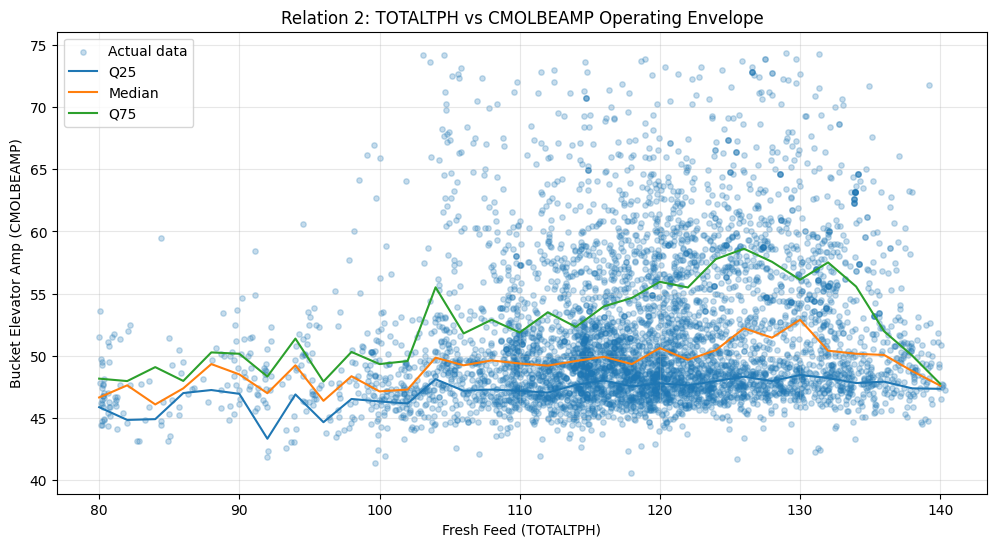

In [20]:
plt.figure(figsize=(12,6))

plt.scatter(cat0_b["TOTALTPH"], cat0_b["CMOLBEAMP"], alpha=0.25, s=15, label="Actual data")

plt.plot(amp_env["feed_bin_start"], amp_env["amp_q25"], label="Q25")
plt.plot(amp_env["feed_bin_start"], amp_env["amp_median"], label="Median")
plt.plot(amp_env["feed_bin_start"], amp_env["amp_q75"], label="Q75")

plt.xlabel("Fresh Feed (TOTALTPH)")
plt.ylabel("Bucket Elevator Amp (CMOLBEAMP)")
plt.title("Relation 2: TOTALTPH vs CMOLBEAMP Operating Envelope")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

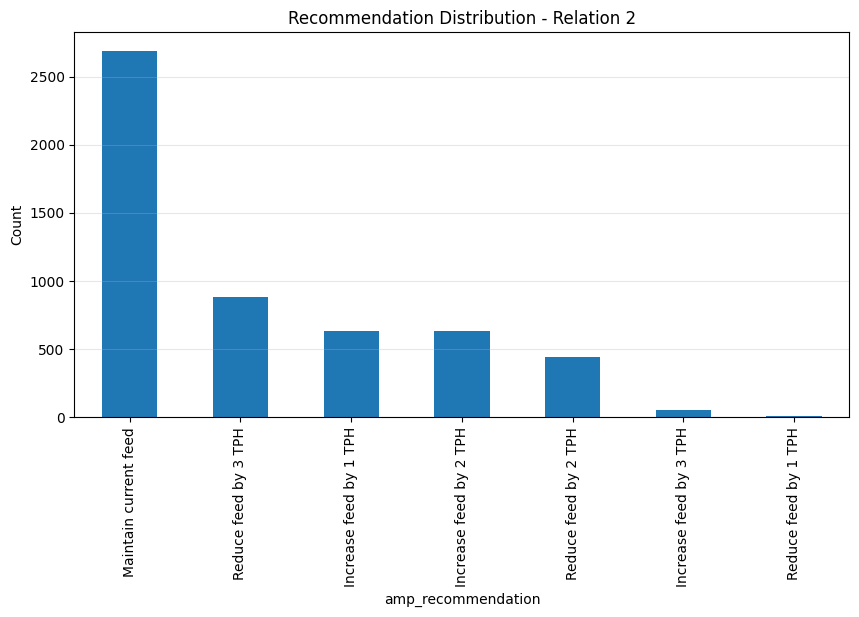

In [21]:
cat0_b["amp_recommendation"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Recommendation Distribution - Relation 2")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Lets create a function after validation for both categories 

In [22]:
def build_relation2_amp(data, min_tph=60, bin_width=2, min_bin_count=5):
    df = data.copy()

    # Basic cleaning
    df = df[
        (df["TOTALTPH"] > min_tph) &
        (df["CMOLBEAMP"] > 0)
    ].copy()

    # Outlier removal
    tph_upper = df["TOTALTPH"].quantile(0.99)
    amp_upper = df["CMOLBEAMP"].quantile(0.99)

    df = df[
        (df["TOTALTPH"] <= tph_upper) &
        (df["CMOLBEAMP"] <= amp_upper)
    ].copy()

    # Feed bins
    df["feed_bin_start"] = (df["TOTALTPH"] // bin_width) * bin_width
    df["feed_bin_end"] = df["feed_bin_start"] + bin_width
    df["feed_bin"] = (
        df["feed_bin_start"].astype(int).astype(str) + "-" +
        df["feed_bin_end"].astype(int).astype(str)
    )

    # Envelope
    env = (
        df.groupby("feed_bin_start")["CMOLBEAMP"]
        .agg(
            amp_q25=lambda x: x.quantile(0.25),
            amp_median="median",
            amp_q75=lambda x: x.quantile(0.75),
            count="count"
        )
        .reset_index()
    )

    env = env[env["count"] >= min_bin_count].copy()
    env["feed_bin_end"] = env["feed_bin_start"] + bin_width
    env["feed_bin"] = (
        env["feed_bin_start"].astype(int).astype(str) + "-" +
        env["feed_bin_end"].astype(int).astype(str)
    )

    # Merge
    df = df.merge(
        env[["feed_bin_start", "amp_q25", "amp_median", "amp_q75"]],
        on="feed_bin_start",
        how="left"
    )

    # Classification
    def classify_amp(row):
        if pd.isna(row["amp_q25"]) or pd.isna(row["amp_q75"]):
            return np.nan
        elif row["CMOLBEAMP"] < row["amp_q25"]:
            return "Low circulation"
        elif row["CMOLBEAMP"] > row["amp_q75"]:
            return "High circulation"
        else:
            return "Stable"

    df["amp_status"] = df.apply(classify_amp, axis=1)

    # Deviation / severity
    df["amp_deviation"] = df["CMOLBEAMP"] - df["amp_median"]
    df["amp_bandwidth"] = df["amp_q75"] - df["amp_q25"]
    df["amp_bandwidth"] = df["amp_bandwidth"].replace(0, np.nan)
    df["amp_severity"] = df["amp_deviation"] / df["amp_bandwidth"]

    # Recommendation
    def amp_recommendation(row):
        if pd.isna(row["amp_status"]) or pd.isna(row["amp_severity"]):
            return np.nan

        sev = abs(row["amp_severity"])

        if row["amp_status"] == "Stable":
            return "Maintain current feed"
        elif row["amp_status"] == "Low circulation":
            if sev < 0.5:
                return "Increase feed by 1 TPH"
            elif sev < 1.0:
                return "Increase feed by 2 TPH"
            else:
                return "Increase feed by 3 TPH"
        elif row["amp_status"] == "High circulation":
            if sev < 0.5:
                return "Reduce feed by 1 TPH"
            elif sev < 1.0:
                return "Reduce feed by 2 TPH"
            else:
                return "Reduce feed by 3 TPH"

        return np.nan

    df["amp_recommendation"] = df.apply(amp_recommendation, axis=1)

    return df, env

In [23]:
cat0_r2, cat0_env2 = build_relation2_amp(cat0)
cat1_r2, cat1_env2 = build_relation2_amp(cat1)

# For Category 1 PPC

In [26]:
cat1_r2[final_cols]

,Timestamp,TOTALTPH,CMOLBEAMP,feed_bin,amp_q25,amp_median,amp_q75,amp_status,amp_deviation,amp_severity,amp_recommendation
0,2025-01-01 21:00:00,91.679859,56.117218,90-92,45.470085,47.863247,51.868134,High circulation,8.253971,1.290076,Reduce feed by 3 TPH
1,2025-01-02 13:00:00,97.543351,58.021980,96-98,47.032967,50.134312,54.566548,High circulation,7.887669,1.047001,Reduce feed by 3 TPH
2,2025-01-02 20:00:00,122.287914,71.746033,122-124,57.997561,65.396828,68.888891,High circulation,6.349205,0.582960,Reduce feed by 2 TPH
3,2025-01-02 21:00:00,121.526989,73.504272,120-122,58.876680,64.102566,67.863249,High circulation,9.401707,1.046195,Reduce feed by 3 TPH
4,2025-01-02 22:00:00,123.579004,66.666672,122-124,57.997561,65.396828,68.888891,Stable,1.269844,0.116592,Maintain current feed
...,...,...,...,...,...,...,...,...,...,...,...
2007,2026-01-27 23:00:00,116.188033,58.021980,116-118,56.800980,61.562883,66.275948,Stable,-3.540903,-0.373711,Maintain current feed
2008,2026-01-30 16:00:00,99.494508,50.793655,98-100,50.830285,55.433458,58.656901,Low circulation,-4.639803,-0.592824,Increase feed by 2 TPH
2009,2026-01-30 17:00:00,102.671549,53.528698,102-104,48.864470,52.014656,56.263739,Stable,1.514042,0.204620,Maintain current feed
2010,2026-01-30 18:00:00,108.732602,58.754581,108-110,51.221005,54.725279,60.476193,Stable,4.029303,0.435356,Maintain current feed


# For category 0 OPC

In [27]:
cat0_r2[final_cols]

,Timestamp,TOTALTPH,CMOLBEAMP,feed_bin,amp_q25,amp_median,amp_q75,amp_status,amp_deviation,amp_severity,amp_recommendation
0,2025-01-01 00:00:00,121.751163,53.626377,120-122,47.777778,50.622713,55.946280,Stable,3.003664,0.367713,Maintain current feed
1,2025-01-01 01:00:00,119.021003,54.993896,118-120,47.521366,49.328449,54.652016,High circulation,5.665447,0.794520,Reduce feed by 2 TPH
2,2025-01-01 02:00:00,122.926258,57.582420,122-124,47.619049,49.670330,55.494510,High circulation,7.912090,1.004651,Reduce feed by 3 TPH
3,2025-01-01 03:00:00,121.687425,53.040295,120-122,47.777778,50.622713,55.946280,Stable,2.417582,0.295964,Maintain current feed
4,2025-01-01 04:00:00,122.418812,57.533581,122-124,47.619049,49.670330,55.494510,High circulation,7.863251,0.998450,Reduce feed by 2 TPH
...,...,...,...,...,...,...,...,...,...,...,...
5403,2026-01-30 15:00:00,107.122108,59.780224,106-108,47.179489,49.230770,51.794874,High circulation,10.549454,2.285715,Reduce feed by 3 TPH
5404,2026-01-30 20:00:00,99.130651,66.178268,98-100,46.520147,48.351650,50.305252,High circulation,17.826618,4.709676,Reduce feed by 3 TPH
5405,2026-01-30 21:00:00,104.230777,52.356537,104-106,48.107449,49.841270,55.506719,Stable,2.515266,0.339934,Maintain current feed
5406,2026-01-30 22:00:00,104.261301,55.286938,104-106,48.107449,49.841270,55.506719,Stable,5.445667,0.735974,Maintain current feed
